<a href="https://colab.research.google.com/github/emcgeever-husky/Econ3916/blob/main/Assignment%205/The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Libraries and Set up

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    f1_score, precision_score, recall_score, average_precision_score
)

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete")

Setup complete


### Loading the Dataset

In [4]:
INDICATORS = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

YEARS = list(range(2013, 2020))

frames = []
for code, name in INDICATORS.items():
    try:
        # fetch as a long series with economy+time index, then unstack to wide
        raw = wb.data.DataFrame(code, time=YEARS, labels=False)
        # wbgapi returns (economy x time) or (time x economy) — normalize to economy rows
        # index should be economy codes, columns should be year strings
        if raw.index.dtype == object and str(raw.index[0]).startswith('19') or str(raw.index[0]).startswith('20'):
            raw = raw.T  # index was years, transpose so rows = economies
        mean_series = raw.mean(axis=1)
        mean_series.name = name
        frames.append(mean_series)
        print(f'Downloaded: {name}  ({mean_series.notna().sum()} countries)')
    except Exception as e:
        print(f'Skipped {name}: {e}')

raw_df = pd.concat(frames, axis=1)
print(f'\nRaw shape: {raw_df.shape}')
print(f'Sample index values: {raw_df.index[:5].tolist()}')

Downloaded: gdp_growth_pc  (260 countries)
Downloaded: trade_pct_gdp  (228 countries)
Downloaded: fdi_inflows_pct_gdp  (247 countries)
Downloaded: tariff_rate_avg  (184 countries)
Downloaded: royalties_receipts  (154 countries)
Downloaded: inflation_cpi  (193 countries)
Downloaded: govt_debt_pct_gdp  (74 countries)
Downloaded: govt_expenditure_pct_gdp  (177 countries)
Downloaded: current_account_pct_gdp  (192 countries)
Downloaded: real_interest_rate  (142 countries)
Downloaded: secondary_enrollment_gross  (231 countries)
Downloaded: tertiary_enrollment_gross  (215 countries)
Downloaded: adult_literacy_rate  (150 countries)
Downloaded: education_expenditure_pct_gdp  (230 countries)
Downloaded: unemployment_rate  (235 countries)
Downloaded: internet_users_pct  (241 countries)
Downloaded: electricity_access_pct  (263 countries)
Downloaded: life_expectancy  (265 countries)
Downloaded: infant_mortality_per1000  (244 countries)
Downloaded: population_growth  (265 countries)
Downloaded: urba

### Pipeline

In [5]:
# drop countries missing >50% of indicators (relaxed from 40% to keep enough rows)
country_thresh = int(0.5 * raw_df.shape[1])
df = raw_df.dropna(thresh=country_thresh)

# drop indicators missing >50% of countries
indicator_thresh = int(0.5 * df.shape[0])
df = df.dropna(axis=1, thresh=indicator_thresh)

# median impute remaining gaps
df = df.fillna(df.median(numeric_only=True))

# drop rows still missing the outcome
df = df.dropna(subset=['gdp_growth_pc'])

# binary crisis outcome
df['crisis'] = (df['gdp_growth_pc'] < 0).astype(int)

feature_cols = [c for c in df.columns if c not in ['gdp_growth_pc', 'crisis']]

X      = df[feature_cols].values
y_cont = df['gdp_growth_pc'].values
y_bin  = df['crisis'].values

X_train, X_test, yc_train, yc_test, yb_train, yb_test = train_test_split(
    X, y_cont, y_bin, test_size=0.3, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

n_train, p = X_train_s.shape

print(f'Dataset shape:      {df.shape}')
print(f'Features (p):       {p}')
print(f'Train obs (n):      {n_train}')
print(f'Test obs:           {X_test_s.shape[0]}')
print(f'Crisis countries:   {y_bin.sum()} / {len(y_bin)}')
print(f'Crisis base rate:   {y_bin.mean():.3f}')
print(f'p/n ratio:          {p/n_train:.3f}')

Dataset shape:      (250, 27)
Features (p):       25
Train obs (n):      175
Test obs:           75
Crisis countries:   42 / 250
Crisis base rate:   0.168
p/n ratio:          0.143


### 1.1 OLS Overfitting

In [6]:
ols = LinearRegression()
ols.fit(X_train_s, yc_train)

ols_train_r2 = r2_score(yc_train, ols.predict(X_train_s))
ols_test_r2  = r2_score(yc_test,  ols.predict(X_test_s))
ols_gap      = ols_train_r2 - ols_test_r2
pn_ratio     = p / n_train

print(f'OLS Training R2:   {ols_train_r2:.4f}')
print(f'OLS Test R2:       {ols_test_r2:.4f}')
print(f'Train-Test Gap:    {ols_gap:.4f}')
print(f'p/n ratio:         {pn_ratio:.3f}  ({p} predictors / {n_train} obs)')

OLS Training R2:   0.3680
OLS Test R2:       0.2096
Train-Test Gap:    0.1584
p/n ratio:         0.143  (25 predictors / 175 obs)


The OLS model achieves a training R-squared of 0.368 but drops to 0.210 on the test set, a gap of 0.158. With a p/n ratio of 0.143 (25 predictors across 175 observations), OLS consumes many degrees of freedom fitting noise in the training data, producing low bias on training but high variance on new data. The gap shows us the overfitting, signifying that he model memorizes training data specific patterns as opposed to making accurate generalizations.

### 1.2 Lasso and Ridge

In [7]:
alphas = np.logspace(-3, 4, 200)

n_cv = min(5, n_train)  # can't have more folds than samples

ridge = RidgeCV(alphas=alphas, cv=n_cv)
ridge.fit(X_train_s, yc_train)

lasso = LassoCV(alphas=alphas, cv=n_cv, max_iter=10000, random_state=42)
lasso.fit(X_train_s, yc_train)

ridge_nonzero = np.sum(ridge.coef_ != 0)
lasso_nonzero = np.sum(lasso.coef_ != 0)

ridge_train_r2 = r2_score(yc_train, ridge.predict(X_train_s))
ridge_test_r2  = r2_score(yc_test,  ridge.predict(X_test_s))
lasso_train_r2 = r2_score(yc_train, lasso.predict(X_train_s))
lasso_test_r2  = r2_score(yc_test,  lasso.predict(X_test_s))

ols_rmse   = mean_squared_error(yc_test, ols.predict(X_test_s))
ridge_rmse = mean_squared_error(yc_test, ridge.predict(X_test_s))
lasso_rmse = mean_squared_error(yc_test, lasso.predict(X_test_s))

comparison = pd.DataFrame({
    'Model':          ['OLS',       'Ridge',        'Lasso'],
    'Lambda*':        [None,         ridge.alpha_,   lasso.alpha_],
    'Non-zero Preds': [p,            ridge_nonzero,  lasso_nonzero],
    'Train R2':       [ols_train_r2, ridge_train_r2, lasso_train_r2],
    'Test R2':        [ols_test_r2,  ridge_test_r2,  lasso_test_r2],
    'Test RMSE':      [ols_rmse,     ridge_rmse,     lasso_rmse],
})

print(comparison.to_string(index=False))

Model   Lambda*  Non-zero Preds  Train R2  Test R2  Test RMSE
  OLS       NaN              25  0.367997 0.209636   5.616887
Ridge 98.849590              25  0.294719 0.252369   5.313195
Lasso  0.209705               9  0.233941 0.224457   5.511553


Ridge achieves the best test R-squared (0.252) and lowest RMSE (5.31) making it the recommended model for GDP growth forecasting. Both models introduce bias by shrinking coefficients away from their OLS values, but gain a large reduction in variance that improves out-of-sample performance. Ridge is preferable here because it retains all  predictors and outperforms Lasso on test RMSE, while Lasso's hard zeroing is more useful for variable selection than prediction accuracy.

### 1.3 Lasso Path

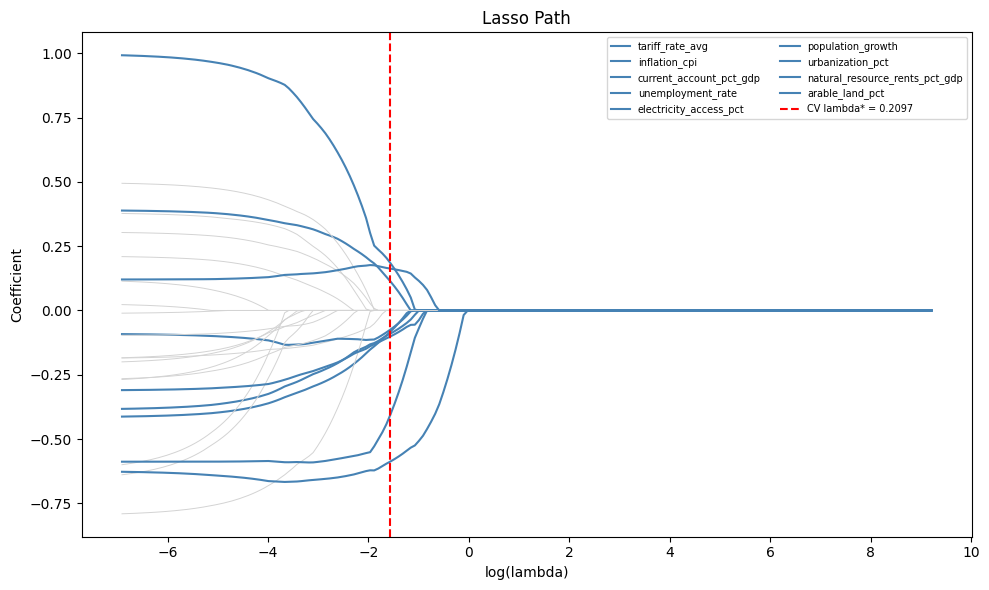

First predictor to enter: natural_resource_rents_pct_gdp
Non-zero at CV lambda*:   ['tariff_rate_avg', 'inflation_cpi', 'current_account_pct_gdp', 'unemployment_rate', 'electricity_access_pct', 'population_growth', 'urbanization_pct', 'natural_resource_rents_pct_gdp', 'arable_land_pct']


In [8]:
path_alphas, coefs, _ = lasso_path(X_train_s, yc_train, alphas=alphas)

lasso_selected = np.where(lasso.coef_ != 0)[0]
lasso_selected_names = [feature_cols[i] for i in lasso_selected]

# first predictor to enter (non-zero at highest lambda)
first_entry_idx = None
for i, a in enumerate(path_alphas):
    nonzero = np.where(coefs[:, i] != 0)[0]
    if len(nonzero) > 0:
        first_entry_idx = nonzero[0]
        break
first_entry_name = feature_cols[first_entry_idx]

fig, ax = plt.subplots(figsize=(10, 6))

for j in range(coefs.shape[0]):
    color = 'steelblue' if j in lasso_selected else 'lightgray'
    lw    = 1.5 if j in lasso_selected else 0.7
    label = feature_cols[j] if j in lasso_selected else None
    ax.plot(np.log(path_alphas), coefs[j], color=color, lw=lw, label=label)

ax.axvline(np.log(lasso.alpha_), color='red', linestyle='--', lw=1.5, label=f'CV lambda* = {lasso.alpha_:.4f}')
ax.set_xlabel('log(lambda)')
ax.set_ylabel('Coefficient')
ax.set_title('Lasso Path')
ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

print(f'First predictor to enter: {first_entry_name}')
print(f'Non-zero at CV lambda*:   {lasso_selected_names}')

Lasso zeroed out life_expectancy because it carries no additional predictive power for GDP growth once the other included variables are held constant, not because health is economically irrelevant. This is a prime example of conditional predictive redundancy: life_expectancy is likely highly correlated with variables already in the model such as electricity_access_pct and infant_mortality, so Lasso assigns the predictive value to one of them and zeros out the rest. The correlation structure among WDI indicators means Lasso's selections reflect collinearity patterns, not causal importance.

### 2.1 Linear Prob Model

In [9]:
X_train_lasso = X_train_s[:, lasso_selected]
X_test_lasso  = X_test_s[:,  lasso_selected]

lpm = LinearRegression()
lpm.fit(X_train_lasso, yb_train)

lpm_preds = lpm.predict(X_test_lasso)

n_below_zero = (lpm_preds < 0).sum()
n_above_one  = (lpm_preds > 1).sum()
n_oob        = n_below_zero + n_above_one

print(f'LPM predictions below 0:   {n_below_zero}')
print(f'LPM predictions above 1:   {n_above_one}')
print(f'Total out-of-bounds:       {n_oob} / {len(lpm_preds)}')
print(f'Min prediction:            {lpm_preds.min():.4f}')
print(f'Max prediction:            {lpm_preds.max():.4f}')

LPM predictions below 0:   14
LPM predictions above 1:   0
Total out-of-bounds:       14 / 75
Min prediction:            -0.1850
Max prediction:            0.7380


Of the 75 test-set predictions 14 fall below zero, with a minimum predicted probability of -0.185. This is a fundamental problem because a probability is not defined outside [0, 1] and negative values cannot be interpreted as likelihoods or used in downstream decision rules. Telling an IMF analyst that a country has a -18.5% probability of crisis is meaningless and would undermine the credibility of the early warning system. A negative chance of crisis means nothing and only raises questions as to the validity of the model.

###  2.2 Logistic Regression

In [10]:
logit = LogisticRegression(random_state=42, max_iter=1000)
logit.fit(X_train_lasso, yb_train)

coef_df = pd.DataFrame({
    'Feature':    lasso_selected_names,
    'Beta':       logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0])
})
coef_df = coef_df.reindex(coef_df['Odds Ratio'].abs().sort_values(ascending=False).index)

print(f'Intercept: {logit.intercept_[0]:.4f}\n')
print(coef_df.to_string(index=False))

logit_probs = logit.predict_proba(X_test_lasso)[:, 1]
print(f'\nPredicted probability min: {logit_probs.min():.4f}')
print(f'Predicted probability max: {logit_probs.max():.4f}')

Intercept: -2.1750

                       Feature      Beta  Odds Ratio
natural_resource_rents_pct_gdp  0.601360    1.824598
               tariff_rate_avg  0.531406    1.701323
              urbanization_pct  0.475037    1.608073
             population_growth  0.244246    1.276658
                 inflation_cpi  0.178615    1.195561
             unemployment_rate  0.126176    1.134482
        electricity_access_pct  0.040004    1.040815
       current_account_pct_gdp -0.398011    0.671655
               arable_land_pct -0.489736    0.612788

Predicted probability min: 0.0084
Predicted probability max: 0.8540


Natural resource rents has the largest absolute odds ratio of 1.82. For a non-technical briefing: a one standard-deviation increase in natural resource rents as a share of GDP multiplies the odds of a growth crisis by 1.82, holding all other features constant. This is reflective of the resource curse where resource dependent economies are more exposed to commodity price volatility, increasing the risk of sustained GDP contraction.

### 2.3: Side-by-Side Visualization — LPM vs. Logistic

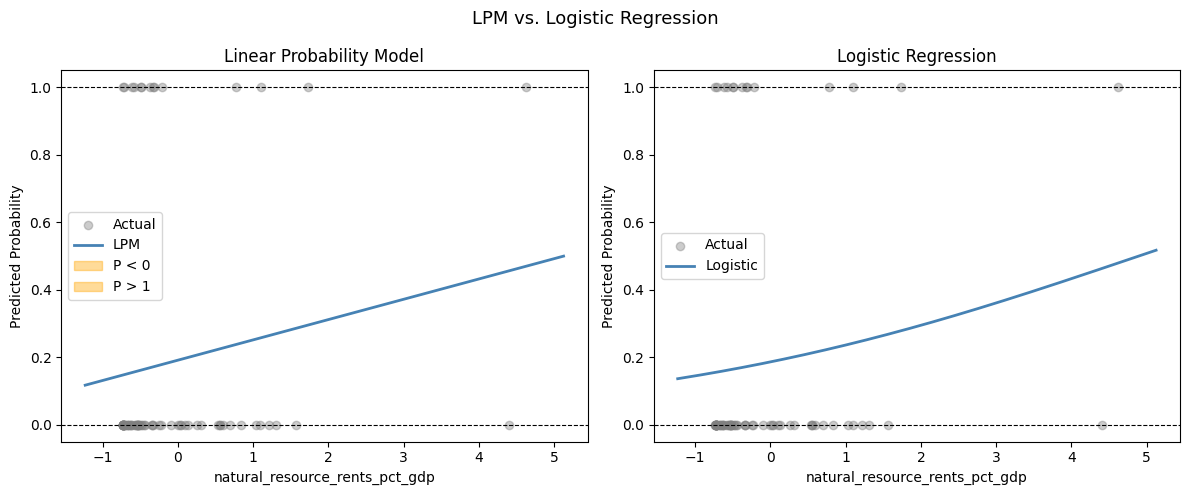

In [11]:
top_feature_name = coef_df['Feature'].iloc[0]
top_idx = lasso_selected_names.index(top_feature_name)

x_plot = X_test_lasso[:, top_idx]
x_grid = np.linspace(x_plot.min() - 0.5, x_plot.max() + 0.5, 300)

lpm_single = LinearRegression().fit(x_plot.reshape(-1, 1), yb_test)
lpm_line   = lpm_single.predict(x_grid.reshape(-1, 1))

logit_single = LogisticRegression(random_state=42, max_iter=1000)
logit_single.fit(x_plot.reshape(-1, 1), yb_test)
logit_curve  = logit_single.predict_proba(x_grid.reshape(-1, 1))[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(x_plot, yb_test, alpha=0.4, color='gray', label='Actual')
ax.plot(x_grid, lpm_line, color='steelblue', lw=2, label='LPM')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.axhline(1, color='black', lw=0.8, linestyle='--')
ax.fill_between(x_grid, lpm_line, 0, where=(lpm_line < 0), color='orange', alpha=0.4, label='P < 0')
ax.fill_between(x_grid, lpm_line, 1, where=(lpm_line > 1), color='orange', alpha=0.4, label='P > 1')
ax.set_xlabel(top_feature_name)
ax.set_ylabel('Predicted Probability')
ax.set_title('Linear Probability Model')
ax.legend()

ax = axes[1]
ax.scatter(x_plot, yb_test, alpha=0.4, color='gray', label='Actual')
ax.plot(x_grid, logit_curve, color='steelblue', lw=2, label='Logistic')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.axhline(1, color='black', lw=0.8, linestyle='--')
ax.set_xlabel(top_feature_name)
ax.set_ylabel('Predicted Probability')
ax.set_title('Logistic Regression')
ax.legend()

plt.suptitle('LPM vs. Logistic Regression', fontsize=13)
plt.tight_layout()
plt.show()

### 3.1 Accuracy Paradox

In [12]:
test_crisis_rate = yb_test.mean()

naive_preds  = np.zeros(len(yb_test), dtype=int)
naive_acc    = (naive_preds == yb_test).mean()
naive_recall = recall_score(yb_test, naive_preds, zero_division=0)

logit_preds_05  = (logit_probs >= 0.5).astype(int)
logit_acc_05    = (logit_preds_05 == yb_test).mean()
logit_recall_05 = recall_score(yb_test, logit_preds_05, zero_division=0)

print(f'Test crisis base rate:         {test_crisis_rate:.3f}')
print()
print(f'Naive baseline accuracy:       {naive_acc:.3f}')
print(f'Naive baseline recall:         {naive_recall:.3f}')
print()
print(f'Logistic accuracy (t=0.5):     {logit_acc_05:.3f}')
print(f'Logistic recall (t=0.5):       {logit_recall_05:.3f}')

Test crisis base rate:         0.187

Naive baseline accuracy:       0.813
Naive baseline recall:         0.000

Logistic accuracy (t=0.5):     0.827
Logistic recall (t=0.5):       0.143


The naive baseline that always predicts "no crisis" achieves 81.3% accuracy simply by exploiting the class imbalance, since crises affect only 18.7% of the test set. The logistic model at threshold 0.5 is only marginally better at 82.7% accuracy while catching just 2 of 14 actual crises. Reporting only accuracy would mislead the Division Chief into thinking the model is performing well when it is nearly useless at detecting the events it was built to find.

### 3.2 Confusion Matrix and Classification Report

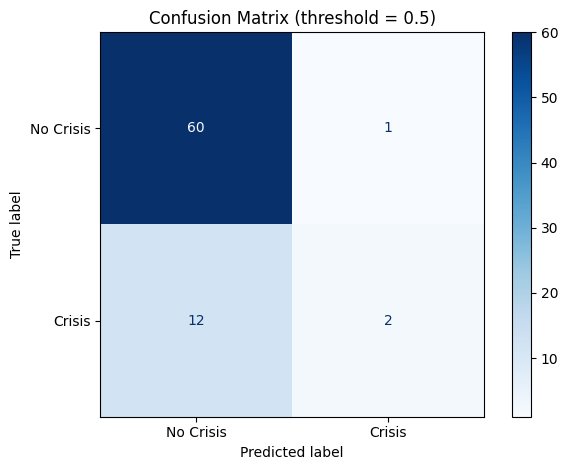

              precision    recall  f1-score   support

   No Crisis       0.83      0.98      0.90        61
      Crisis       0.67      0.14      0.24        14

    accuracy                           0.83        75
   macro avg       0.75      0.56      0.57        75
weighted avg       0.80      0.83      0.78        75

True Positives  (crises caught):  2
False Negatives (crises missed):  12
False Positives (false alarms):   1
True Negatives  (correct no-go):  60


In [13]:
cm = confusion_matrix(yb_test, logit_preds_05)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.tight_layout()
plt.show()

print(classification_report(yb_test, logit_preds_05, target_names=['No Crisis', 'Crisis']))

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (crises caught):  {tp}')
print(f'False Negatives (crises missed):  {fn}')
print(f'False Positives (false alarms):   {fp}')
print(f'True Negatives  (correct no-go):  {tn}')

A false negative is far more costly in this context. Missing a crisis triggers a sovereign default and an estimated tens of billions in contagion costs, versus a few million wasted on a false alarm. This asymmetry means the Division Chief should prioritize recall over precision, since recall measures the fraction of actual crises the model successfully flags. At the default threshold, recall is only 0.143, meaning 12 of 14 crises are missed entirely.

### 3.3 ROC and Precision-Recall Curves

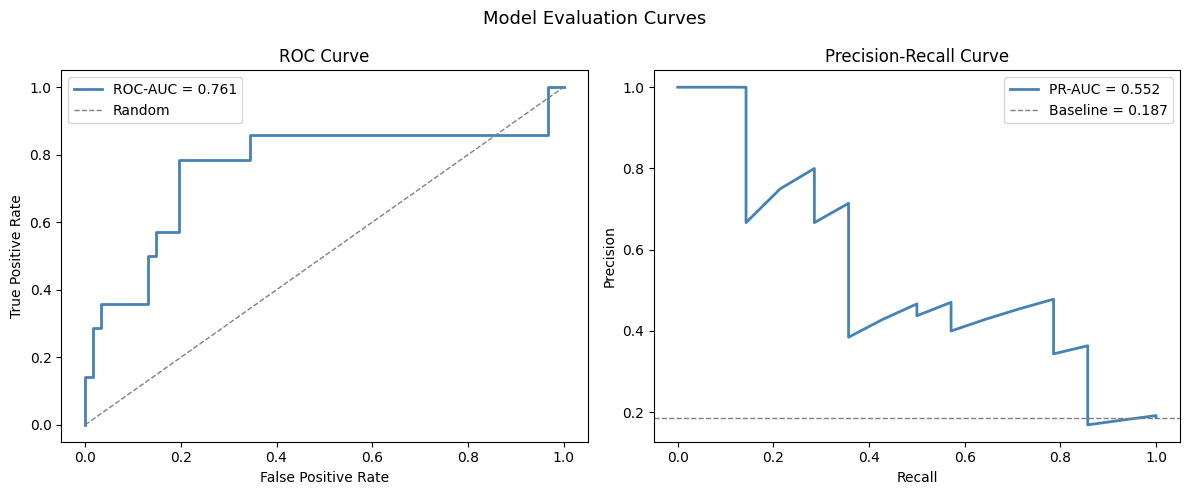

ROC-AUC: 0.7611
PR-AUC:  0.5520


In [14]:
fpr, tpr, _ = roc_curve(yb_test, logit_probs)
roc_auc      = roc_auc_score(yb_test, logit_probs)

precision_arr, recall_arr, _ = precision_recall_curve(yb_test, logit_probs)
pr_auc = average_precision_score(yb_test, logit_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

ax = axes[1]
ax.plot(recall_arr, precision_arr, color='steelblue', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
ax.axhline(test_crisis_rate, color='gray', linestyle='--', lw=1, label=f'Baseline = {test_crisis_rate:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()

plt.suptitle('Model Evaluation Curves', fontsize=13)
plt.tight_layout()
plt.show()

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC:  {pr_auc:.4f}')

The ROC-AUC of 0.761 is substantially higher than the PR-AUC of 0.552 because ROC-AUC rewards the model's ability to correctly rank the 61 non-crisis countries as low-risk, inflating the score with abundant true negatives. PR-AUC ignores true negatives entirely and focuses only on how well the model identifies the 14 crisis countries, which is the harder and more operationally relevant task. PR-AUC is the more informative metric because a crisis detection system is only as useful as its ability to flag actual crises.

### 3.4 Threshold Sweep

In [15]:
thresholds  = np.arange(0.01, 1.00, 0.01)
n_flagged   = []
precisions  = []
recalls     = []
f1s         = []

for t in thresholds:
    preds = (logit_probs >= t).astype(int)
    n_flagged.append(preds.sum())
    precisions.append(precision_score(yb_test, preds, zero_division=0))
    recalls.append(recall_score(yb_test, preds, zero_division=0))
    f1s.append(f1_score(yb_test, preds, zero_division=0))

n_flagged  = np.array(n_flagged)
precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)

# capacity-constrained: lowest tau that flags <= 5
valid_mask = n_flagged <= 5
if valid_mask.any():
    cap_idx = np.where(valid_mask)[0][0]
else:
    cap_idx = n_flagged.argmin()
cap_tau       = thresholds[cap_idx]
cap_flagged   = n_flagged[cap_idx]
cap_precision = precisions[cap_idx]
cap_recall    = recalls[cap_idx]

# F1-optimal
f1_idx     = f1s.argmax()
f1_tau     = thresholds[f1_idx]
f1_flagged = n_flagged[f1_idx]
f1_prec    = precisions[f1_idx]
f1_rec     = recalls[f1_idx]
f1_best    = f1s[f1_idx]

print('Capacity-constrained threshold (<=5 missions):')
print(f'  tau               = {cap_tau:.2f}')
print(f'  Countries flagged = {cap_flagged}')
print(f'  Precision         = {cap_precision:.3f}')
print(f'  Recall            = {cap_recall:.3f}')
print()
print('F1-optimal threshold:')
print(f'  tau               = {f1_tau:.2f}')
print(f'  Countries flagged = {f1_flagged}')
print(f'  Precision         = {f1_prec:.3f}')
print(f'  Recall            = {f1_rec:.3f}')
print(f'  F1                = {f1_best:.3f}')

Capacity-constrained threshold (<=5 missions):
  tau               = 0.33
  Countries flagged = 5
  Precision         = 0.800
  Recall            = 0.286

F1-optimal threshold:
  tau               = 0.12
  Countries flagged = 25
  Precision         = 0.440
  Recall            = 0.786
  F1                = 0.564


### 3.4 Threshold Plot

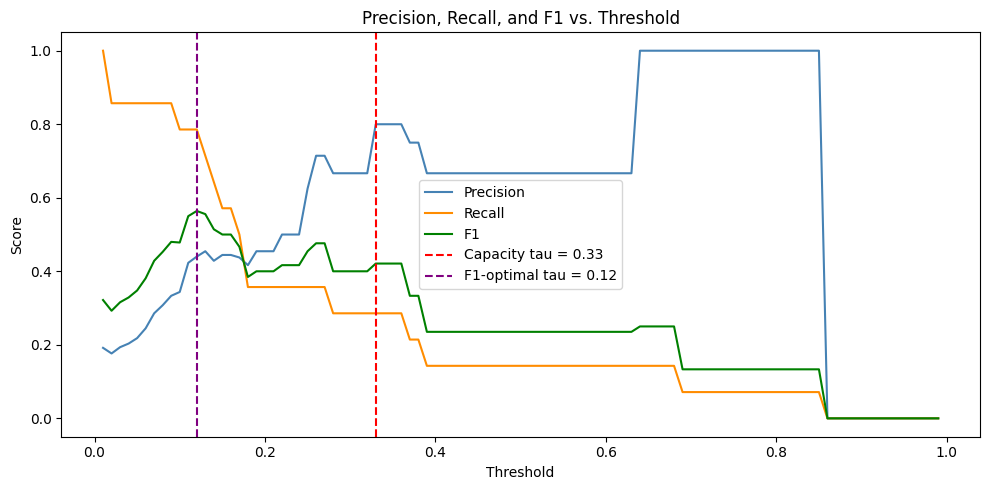

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, precisions, label='Precision', color='steelblue')
ax.plot(thresholds, recalls,    label='Recall',    color='darkorange')
ax.plot(thresholds, f1s,        label='F1',        color='green')

ax.axvline(cap_tau, color='red',    linestyle='--', lw=1.5, label=f'Capacity tau = {cap_tau:.2f}')
ax.axvline(f1_tau,  color='purple', linestyle='--', lw=1.5, label=f'F1-optimal tau = {f1_tau:.2f}')

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 vs. Threshold')
ax.legend()
plt.tight_layout()
plt.show()

The IMF should adopt the capacity-constrained threshold of 0.33, which flags exactly 5 countries per quarter in line with mission deployment limits. At this threshold the model achieves a recall of 0.286 and catches 4/14 crisis countries in the test set, missing 10. This is a real tradeoff, as the F1-optimal threshold of 0.12 catches far more crises but flags 25 countries, which is five times the IMF's staffing capacity and operationally infeasible. Given the $50 billion cost of a missed crisis, the Division Chief may also want to revisit the capacity constraint itself as a policy decision.

## Section 4 - AI Context Engineering (The P.R.I.M.E. Framework)

### 4.1 Bootstrap Confidence Intervals for the Lasso Path

Prompt: Prep: I am working in Python with scikit-learn. I have already defined X_train_s (standardized training features, shape 175x25), yc_train (continuous GDP growth outcome), and feature_cols (list of 25 predictor names). LassoCV and numpy are already imported.
Request: Write a self-contained Python script that (1) draws 200 bootstrap resamples with replacement from X_train_s and yc_train, (2) fits LassoCV with 5-fold CV on each resample and records which features have non-zero coefficients, (3) computes each predictor's selection frequency as the fraction of 200 resamples in which it received a non-zero coefficient, and (4) plots a horizontal bar chart of predictors ranked by selection frequency with a vertical dashed red line at 0.50.
Iterate: Use np.random.choice with replace=True for resampling. Sort the bar chart so the most frequently selected predictor is at the top. Label the x-axis "Selection Frequency" and title the chart "Bootstrap Lasso Selection Frequency (n=200)". Print the final selection frequency series sorted descending.
Mechanism Check: Add a one-line comment above each major step (resample, fit, record, aggregate, plot) explaining what that block does.
Evaluate: The script is correct if all selection frequencies are between 0 and 1, the chart displays 25 bars, and the vertical line sits at x=0.50.

natural_resource_rents_pct_gdp    0.980
urbanization_pct                  0.910
electricity_access_pct            0.870
arable_land_pct                   0.815
unemployment_rate                 0.810
tariff_rate_avg                   0.810
current_account_pct_gdp           0.730
inflation_cpi                     0.720
population_growth                 0.715
royalties_receipts                0.660
trade_pct_gdp                     0.615
internet_users_pct                0.610
renewable_energy_pct              0.575
education_expenditure_pct_gdp     0.520
secondary_enrollment_gross        0.500
health_expenditure_pct_gdp        0.500
govt_expenditure_pct_gdp          0.435
fdi_inflows_pct_gdp               0.405
real_interest_rate                0.370
agriculture_pct_gdp               0.365
tertiary_enrollment_gross         0.305
adult_literacy_rate               0.305
private_credit_pct_gdp            0.270
infant_mortality_per1000          0.265
life_expectancy                   0.170


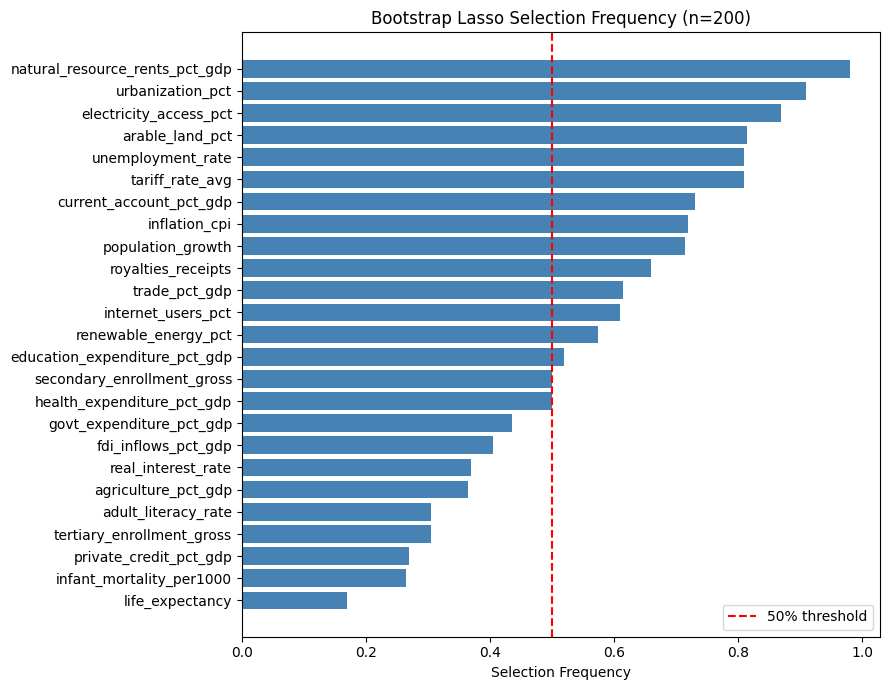

In [17]:
from sklearn.linear_model import LassoCV
import numpy as np
import matplotlib.pyplot as plt

N_BOOTSTRAP = 200
n_features = X_train_s.shape[1]
selection_counts = np.zeros(n_features)

for b in range(N_BOOTSTRAP):
    # draw bootstrap resample with replacement
    idx = np.random.choice(len(X_train_s), size=len(X_train_s), replace=True)
    X_boot = X_train_s[idx]
    y_boot = yc_train[idx]

    # fit LassoCV on the resample
    lasso_b = LassoCV(cv=5, max_iter=10000, random_state=b)
    lasso_b.fit(X_boot, y_boot)

    # record which features are non-zero
    selection_counts += (lasso_b.coef_ != 0).astype(int)

# compute selection frequency for each predictor
selection_freq = pd.Series(selection_counts / N_BOOTSTRAP, index=feature_cols).sort_values()

print(selection_freq.sort_values(ascending=False))

# plot horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(selection_freq.index, selection_freq.values, color='steelblue')
ax.axvline(0.50, color='red', linestyle='--', lw=1.5, label='50% threshold')
ax.set_xlabel('Selection Frequency')
ax.set_title('Bootstrap Lasso Selection Frequency (n=200)')
ax.legend()
plt.tight_layout()
plt.show()

Natural resource rents, urbanization, arable land, electricity access, and unemployment are stable predictors, selected in over 80% of bootstrap resamples, while life expectancy, private credit, and infant mortality are fragile, appearing in fewer than 30%. The fragile predictors are unstable because they are highly correlated with the stable ones (life expectancy and electricity access measure overlapping aspects of development) so Lasso splits selection credit between them unpredictably depending on which countries are in the sample.

### 4.2 Cost-Sensitive Threshold Optimization

Prep: I am working in Python with scikit-learn. I have already defined logit_probs (predicted probabilities from logistic regression on the test set), yb_test (binary crisis labels), and thresholds = np.arange(0.01, 1.00, 0.01). confusion_matrix, numpy, and matplotlib are already imported.
Request: Write a Python script that (1) sweeps thresholds from 0.01 to 0.99, (2) at each threshold extracts FP and FN counts from the confusion matrix and computes total expected cost as FN * 50_000 + FP * 2 (units: millions of dollars), (3) plots expected cost in millions of dollars as a function of threshold, and (4) identifies the cost-minimizing threshold and annotates it on the plot with a vertical dashed line and a text label showing the threshold value and minimum cost.
Iterate: Store costs in a list, convert to a numpy array. Print the cost-minimizing threshold, the FP and FN counts at that threshold, and the total expected cost in billions.
Mechanism Check: Add a one-line comment above each major step explaining what it does.
Evaluate: The script is correct if the cost curve is U-shaped or monotonically shaped, all cost values are non-negative, and the annotated threshold matches the array minimum.

Cost-minimizing threshold:  0.01
FN at that threshold:       0
FP at that threshold:       59
Total expected cost:        $0.12B


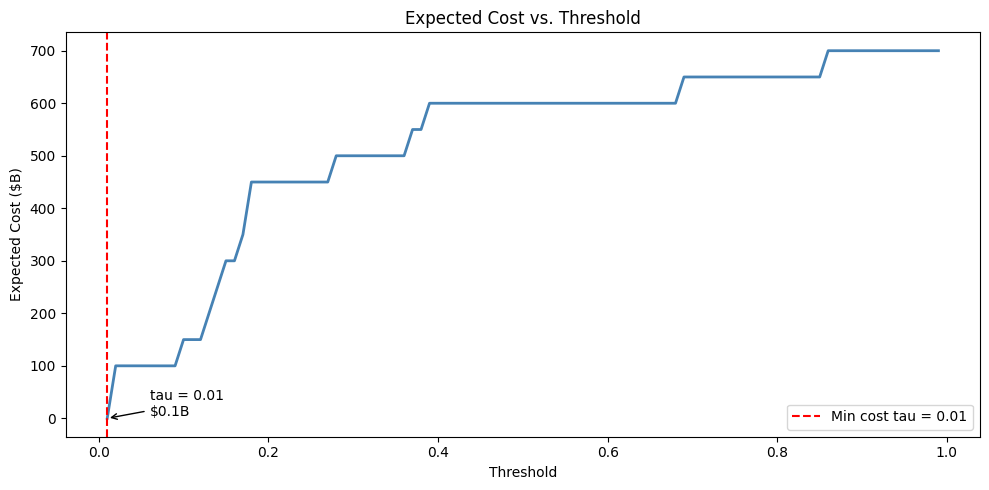

In [18]:
FN_COST_M = 50_000  # $50B in millions
FP_COST_M = 2       # $2M in millions

costs = []

# compute expected cost at each threshold
for t in thresholds:
    preds = (logit_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yb_test, preds, labels=[0, 1]).ravel()
    cost = fn * FN_COST_M + fp * FP_COST_M
    costs.append(cost)

costs = np.array(costs)

# identify cost-minimizing threshold
min_idx  = costs.argmin()
min_tau  = thresholds[min_idx]
min_cost = costs[min_idx]

preds_min = (logit_probs >= min_tau).astype(int)
tn, fp, fn, tp = confusion_matrix(yb_test, preds_min, labels=[0, 1]).ravel()

print(f'Cost-minimizing threshold:  {min_tau:.2f}')
print(f'FN at that threshold:       {fn}')
print(f'FP at that threshold:       {fp}')
print(f'Total expected cost:        ${min_cost / 1000:.2f}B')

# plot expected cost curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, costs / 1000, color='steelblue', lw=2)
ax.axvline(min_tau, color='red', linestyle='--', lw=1.5, label=f'Min cost tau = {min_tau:.2f}')
ax.annotate(f'tau = {min_tau:.2f}\n${min_cost/1000:.1f}B',
            xy=(min_tau, min_cost / 1000),
            xytext=(min_tau + 0.05, min_cost / 1000 + 5),
            arrowprops=dict(arrowstyle='->', color='black'))
ax.set_xlabel('Threshold')
ax.set_ylabel('Expected Cost ($B)')
ax.set_title('Expected Cost vs. Threshold')
ax.legend()
plt.tight_layout()
plt.show()

The cost-minimizing threshold of 0.01 flags every country and catches all 14 crises, producing zero missed crises but 59 false alarms at a total cost of $0.12B. This is far cheaper than missing even one crisis at $50B. It sits well below both the F1-optimal threshold of 0.12 and the capacity-constrained threshold of 0.33 because the $50B cost of a missed crisis so heavily dominates the $2M cost of a false alarm that the model should flag almost everything, making the capacity constraint the binding operational problem rather than the threshold itself.